# Event segmentation and onset detection

This notebook implements the event segmentation pipeline for identifying temporal windows in seismic signals. The pipeline consists of:

1. **Crustal velocity estimation** — Average P-wave and S-wave velocities are computed for each station using the CRUST1.0 global model (Laske et al., 2013)
2. **Theoretical arrival times** — P and S wave theoretical arrivals are calculated using epicentral distances and crustal velocities
3. **Signal conversion** — Long-format acceleration DataFrame is converted to nested dictionary structure for efficient processing
4. **Onset detection** — AR-AIC method (ObsPy) detects P and S onsets using all 3 components simultaneously
5. **Temporal windowing** — Four dynamical regimes are defined: pre-arrival, P-wave, S-wave, and coda

The output is a DataFrame with one row per file (66 rows = 22 stations × 3 components) containing detected onset times and window boundaries for moment scaling analysis.

## 1. Imports and visualization settings

In [5]:
import sys
import pandas as pd
import numpy as np
import logging
from matplotlib import pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from IPython.display import display
from src import (
    add_time_columns,
    convert_signals_to_dict,
    validate_signals_dict,
    add_crustal_velocities,
    add_theoretical_arrivals,
    set_plot_style,
    display_theoretical_arrivals_table,
    plot_theoretical_arrivals,
    theoretical_arrivals_to_latex,
    calculate_search_windows,
    detect_onsets_ar_windowed,
    plot_onset_detection_results
)
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Data loading

Preprocessed metadata and acceleration signals are loaded from parquet files. The metadata contains 66 rows (22 stations × 3 components), while the signals DataFrame is in long format (one row per sample).

In [6]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Define all paths from project root
METADATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '01_metadata'
SIGNALS_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '02_signals'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '03_event_segmentation'
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / 'latex_tables'

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PROCESSED.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(METADATA_PROCESSED.exists(), f"Processed metadata directory ready: {METADATA_PROCESSED}")
check(SIGNALS_PROCESSED.exists(), f"Processed signals directory ready: {SIGNALS_PROCESSED}")

#Load metadata
logger.info("Loading metadata...")
df_meta = pd.read_parquet(METADATA_PROCESSED)
check(df_meta is not None, "Metadata loaded successfully")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata loaded, shape: {df_meta.shape}")

# Load signals
logger.info("Loading acceleration signals...")
df_signals = pd.read_parquet(SIGNALS_PROCESSED / 'acc_preprocessed_scaling.parquet')
check(df_signals is not None, "Signals loaded successfully")
check(len(df_signals) > 0, "Signals dataframe is not empty")
logger.info(f"Signals loaded, shape: {df_signals.shape}")
logger.info(f"Unique files: {df_signals['file'].nunique()}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03_event_segmentation
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables
INFO | Processed metadata directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01_metadata
INFO | Processed signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/02_signals
INFO | Loading metadata...
INFO | Metadata loaded successfully
INFO | Metadata dataframe is not empty
INFO | Metadata loaded, shape: (132, 38)
INFO | Loading acceleration signals...
INFO | Signals loaded successfully
INFO | Signals dataframe is not empty
INFO | Signals loaded, shape: (2614815, 3)
INFO | Unique files: 66


In [7]:
# Check exact file being loaded
signals_file = SIGNALS_PROCESSED / 'acc_preprocessed_scaling.parquet'
print(f"Loading from: {signals_file}")
print(f"File exists: {signals_file.exists()}")

import os
if signals_file.exists():
    print(f"File size: {os.path.getsize(signals_file) / 1e6:.1f} MB")
    print(f"Modified: {pd.Timestamp.fromtimestamp(os.path.getmtime(signals_file))}")
    
# List all files in SIGNALS_PROCESSED directory
print(f"\nAll files in {SIGNALS_PROCESSED}:")
for f in SIGNALS_PROCESSED.glob('*.parquet'):
    size_mb = os.path.getsize(f) / 1e6
    modified = pd.Timestamp.fromtimestamp(os.path.getmtime(f))
    print(f"  {f.name}: {size_mb:.1f} MB, modified {modified}")

Loading from: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/02_signals/acc_preprocessed_scaling.parquet
File exists: True
File size: 22.6 MB
Modified: 2026-04-10 17:26:49.290473

All files in /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/02_signals:
  acc_preprocessed_pdf.parquet: 39.4 MB, modified 2026-04-10 17:26:19.398805
  acc_preprocessed_scaling.parquet: 22.6 MB, modified 2026-04-10 17:26:49.290473


## 3. Metadata preparation

The metadata DataFrame contains 3 rows per station (one for each component: HNE, HNN, HNZ). For crustal velocity estimation and theoretical arrival calculations, we reduce this to 1 row per station, keeping only the essential columns.

In [8]:
logger.info("Preparing station metadata (1 row per station)...")

# Select essential columns and reduce to 1 row per station
df_meta_stations = df_meta.drop_duplicates('STATION_CODE')[[
    'STATION_CODE',
    'STATION_LATITUDE_DEGREE',
    'STATION_LONGITUDE_DEGREE',
    'EPICENTRAL_DISTANCE_KM',
    'INSTRUMENTAL_FREQUENCY_HZ',
    'LOW_CUT_FREQUENCY_HZ',
    'HIGH_CUT_FREQUENCY_HZ',
    'PGA_CM/S^2',
    'TIME_PGA_S',
    'EVENT_DATE',
    'DATE_TIME_FIRST_SAMPLE'
]].copy()

n_stations = len(df_meta_stations)
logger.info(f"Station metadata ready: {n_stations} unique stations")

# Display first rows
print("\nFirst 5 stations:")
display(df_meta_stations.head())

# Summary statistics
print("\nEpicentral distance range:")
print(f"  Min: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].min():.2f} km")
print(f"  Max: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].max():.2f} km")
print(f"  Median: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].median():.2f} km")

INFO | Preparing station metadata (1 row per station)...


INFO | Station metadata ready: 22 unique stations



First 5 stations:


,STATION_CODE,STATION_LATITUDE_DEGREE,STATION_LONGITUDE_DEGREE,EPICENTRAL_DISTANCE_KM,INSTRUMENTAL_FREQUENCY_HZ,LOW_CUT_FREQUENCY_HZ,HIGH_CUT_FREQUENCY_HZ,PGA_CM/S^2,TIME_PGA_S,EVENT_DATE,DATE_TIME_FIRST_SAMPLE
0,EILF,43.547900,7.131200,109.5,200.0,0.5,40.0,0.376358,78.870,2024-12-09 10:41:21,2024-12-09 10:40:40
3,ESCA,43.831000,7.374400,86.5,200.0,0.5,40.0,0.483198,73.185,2024-12-09 10:41:21,2024-12-09 10:40:35
6,ISO,44.184000,7.050000,39.8,200.0,0.4,40.0,0.547306,67.950,2024-12-09 10:41:21,2024-12-09 10:40:26
9,MFC,43.967022,6.919558,60.9,200.0,0.4,40.0,0.339241,71.770,2024-12-09 10:41:21,2024-12-09 10:40:31
12,MON,43.730343,7.424688,98.2,200.0,0.5,20.0,0.114282,75.935,2024-12-09 10:41:21,2024-12-09 10:40:38



Epicentral distance range:
  Min: 4.80 km
  Max: 109.50 km
  Median: 67.80 km


## 4. Crustal velocity estimation

Average P-wave and S-wave velocities are computed for each station location using the CRUST1.0 global crustal model. The model provides velocities for 9 layers (water, ice, 3 sediment layers, 3 crystalline crust layers, mantle) on a 1°×1° grid. We average the velocities across the three crystalline crust layers (upper, middle, lower) to obtain representative crustal velocities.

### References

Laske, G., Masters, G., Ma, Z., & Pasyanos, M. (2013). Update on CRUST1.0 - A 1-degree global model of Earth's crust. *Geophysical Research Abstracts*, 15, EGU2013-2658.

In [9]:
# Add crustal velocities (vp_crust, vs_crust)
df_meta_stations = add_crustal_velocities(
    df_meta_stations,
    lat_col='STATION_LATITUDE_DEGREE',
    lon_col='STATION_LONGITUDE_DEGREE'
)

check('vp_crust' in df_meta_stations.columns, "vp_crust column added")
check('vs_crust' in df_meta_stations.columns, "vs_crust column added")

# Display results
print("\nCrustal velocities (first 5 stations):")
display(df_meta_stations[[
    'STATION_CODE',
    'EPICENTRAL_DISTANCE_KM',
    'vp_crust',
    'vs_crust'
]].head())

INFO | vp_crust column added
INFO | vs_crust column added


Loading CRUST1.0 model...
Querying 22 stations...
Added vp_crust and vs_crust columns
v_P: min=6.33, max=6.73, median=6.33 km/s
v_S: min=3.60, max=3.79, median=3.66 km/s

Crustal velocities (first 5 stations):


,STATION_CODE,EPICENTRAL_DISTANCE_KM,vp_crust,vs_crust
0,EILF,109.5,6.729618,3.789856
3,ESCA,86.5,6.729618,3.789856
6,ISO,39.8,6.331176,3.663886
9,MFC,60.9,6.330868,3.663735
12,MON,98.2,6.729618,3.789856


## 4. Theoretical arrival times

Theoretical P and S wave arrival times are calculated using a simple 1D model:

$$t = t_0 + \frac{d}{v}$$

where $t_0$ is the event origin time (set to 0), $d$ is the epicentral distance, and $v$ is the wave velocity (P or S). These theoretical times provide initial estimates for the onset detection search windows.

In [10]:
logger.info("Calculating theoretical arrival times...")

# Add theoretical arrivals (t_p_theo, t_s_theo)
df_meta_stations = add_theoretical_arrivals(
    df_meta_stations,
    distance_col='EPICENTRAL_DISTANCE_KM'
)

check('t_p_theo' in df_meta_stations.columns, "t_p_theo column added")
check('t_s_theo' in df_meta_stations.columns, "t_s_theo column added")

# Display results
print("\nTheoretical arrivals (first 5 stations):")
display(df_meta_stations[[
    'STATION_CODE',
    'EPICENTRAL_DISTANCE_KM',
    't_p_theo',
    't_s_theo'
]].head())

# Summary
print("\nTheoretical arrival time ranges:")
print(f"  P-wave: {df_meta_stations['t_p_theo'].min():.2f} - {df_meta_stations['t_p_theo'].max():.2f} s")
print(f"  S-wave: {df_meta_stations['t_s_theo'].min():.2f} - {df_meta_stations['t_s_theo'].max():.2f} s")

INFO | Calculating theoretical arrival times...
INFO | t_p_theo column added
INFO | t_s_theo column added


Added theoretical arrival times
  Origin time range: 5.00 - 55.00 s
  t_P range: 5.76 - 61.29 s
  t_S range: 6.31 - 70.72 s

Theoretical arrivals (first 5 stations):


,STATION_CODE,EPICENTRAL_DISTANCE_KM,t_p_theo,t_s_theo
0,EILF,109.5,57.271354,69.892919
3,ESCA,86.5,58.853627,68.824086
6,ISO,39.8,61.286352,65.862783
9,MFC,60.9,59.619533,66.622380
12,MON,98.2,57.592210,68.911275



Theoretical arrival time ranges:
  P-wave: 5.76 - 61.29 s
  S-wave: 6.31 - 70.72 s


## 5.

In [11]:
logger.info("Adding time column to signals...")
df_signals = add_time_columns(df_signals, df_meta, 
                     time_col='DATE_TIME_FIRST_SAMPLE',
                     sampling_interval_col='SAMPLING_INTERVAL_S')
check('time' in df_signals.columns, "Time column added to signals")

INFO | Adding time column to signals...


Added relative time column (t=0 at first sample)
Sampling interval: 0.005 s (200.0 Hz)
Time range: 0.000 - 279.995 s


INFO | Time column added to signals


Added absolute time column
Time range: 2024-12-09 10:40:26 to 2024-12-09 10:45:09.995000
Duration check: Expected 240.00 s, got 198.09 s


## Visualization

Theoretical Arrival Times Summary

Number of stations: 22

Distance range: 4.8 - 109.5 km
P-wave arrival range: 5.8 - 61.3 s
S-wave arrival range: 6.3 - 70.7 s

Median crustal velocities:
  v_P = 6.33 km/s
  v_S = 3.66 km/s

First 10 stations (sorted by distance):


,STATION_CODE,EPICENTRAL_DISTANCE_KM,vp_crust,vs_crust,t_p_theo,t_s_theo
42,SURF,4.8,6.33,3.66,5.76,6.31
48,BRZ,17.4,6.33,3.66,10.97,12.97
51,CRI,32.0,6.33,3.66,25.09,28.77
18,OGAG,39.4,6.33,3.66,61.22,65.75
6,ISO,39.8,6.33,3.66,61.29,65.86
54,SAV,48.0,6.33,3.66,24.96,30.48
45,BHB,48.4,6.33,3.66,18.72,24.29
57,SLZ,53.5,6.33,3.66,24.49,30.64
39,SPIF,59.3,6.33,3.66,60.37,67.19
9,MFC,60.9,6.33,3.66,59.62,66.62


Figure saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03_event_segmentation/theoretical_arrivals.pdf


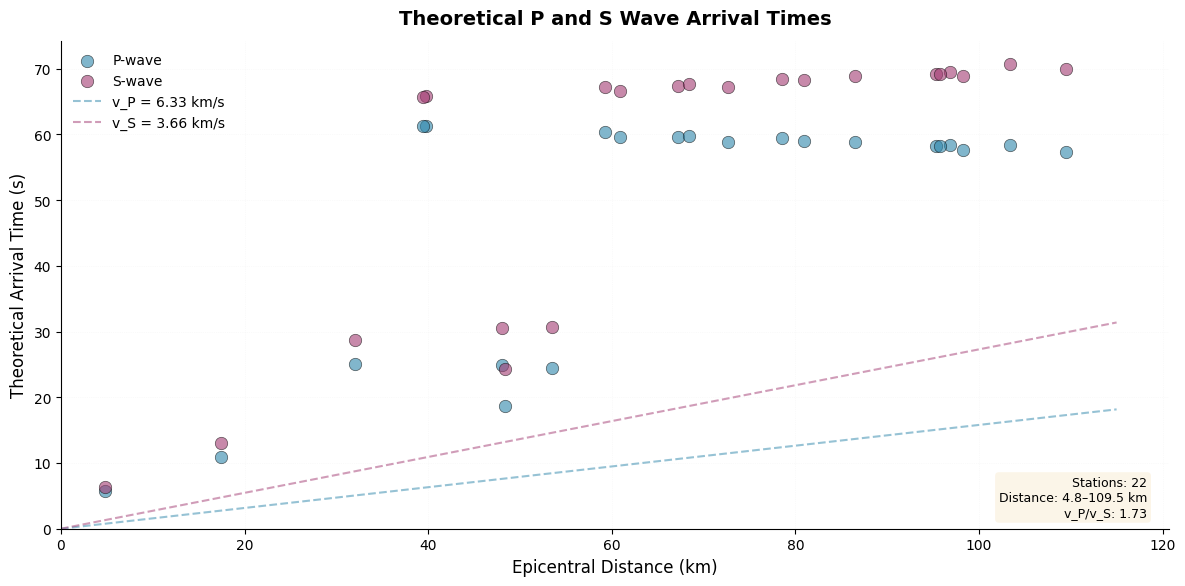

In [12]:
display_theoretical_arrivals_table(df_meta_stations, n_rows=10)

# Plot
fig, ax = plot_theoretical_arrivals(df_meta_stations, 
                                   save_path=FIGURES_DIR / 'theoretical_arrivals.pdf')
plt.show()

In [13]:
latex = theoretical_arrivals_to_latex(
    df_meta_stations,
    output_path=PROJECT_ROOT / 'data' / 'processed' / 'latex_tables' / 'theoretical_arrivals.tex'
)

LaTeX table saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/theoretical_arrivals.tex


## 6. Signal conversion

The acceleration DataFrame in long format (one row per sample) is converted to a nested dictionary structure for efficient access during onset detection:

```python
signals_dict = {
    'SURF': {
        'HNE': array([...]),  # East component
        'HNN': array([...]),  # North component
        'HNZ': array([...]),  # Vertical component
        'time': array([...])  # Time array (shared)
    },
    'BRZ': {...},
    ...
}
```

In [14]:
logger.info("Converting signals to nested dictionary...")

# Convert DataFrame to dict
signals_dict = convert_signals_to_dict(df_signals)

check(len(signals_dict) > 0, "Signals dictionary created")
logger.info(f"Dictionary contains {len(signals_dict)} stations")

# Validate structure
print("\nValidating signals dictionary...")
report = validate_signals_dict(signals_dict)

check(report['valid'], "All signals validated successfully")

INFO | Converting signals to nested dictionary...


Converting 66 files to nested dictionary...


INFO | Signals dictionary created
INFO | Dictionary contains 22 stations
INFO | All signals validated successfully


Converted 66 files
Stations: 22
Components per station: {3}

Validating signals dictionary...
All 22 stations validated


In [15]:

df_meta_stations = calculate_search_windows(df_meta_stations)

df_results_windowed = detect_onsets_ar_windowed(signals_dict, df_meta_stations)

Search windows calculated:
  P-wave: [-15, +15]s around t_p_theo (total width: 30s)
  S-wave: [-20, +20]s around t_s_theo (total width: 40s)

P-wave windows:
  Start: 0.00 - 46.29 s
  End: 20.76 - 76.29 s

S-wave windows:
  Start: 0.00 - 50.72 s
  End: 26.31 - 90.72 s
Running AR-AIC onset detection with theoretical windows...
  P window: [-15, +15]s around t_p_theo
  S window: [-20, +20]s around t_s_theo

Processing: ...................... Done!

Detection summary:
  Total stations: 22
  P successful: 22 (100.0%)
  S successful: 22 (100.0%)
  Both P+S successful: 22 (100.0%)

P-wave residuals:
  Mean: +1.80 s
  Std:  2.31 s
  Range: [-8.01, +3.37] s

S-wave residuals:
  Mean: +4.16 s
  Std:  2.05 s
  Range: [+1.44, +10.09] s


In [16]:
# Check components for failed stations
print("Checking components in signals_dict:\n")

for station in ['EILF', 'SURF', 'BRZ', 'SAV']:
    if station in signals_dict:
        components = [k for k in signals_dict[station].keys() if k != 'time']
        print(f"{station}: {components}")
        
        # Check identification logic
        comp_z = None
        comp_n = None
        comp_e = None
        
        for comp in components:
            print(f"  Testing '{comp}':")
            print(f"    'Z' in comp: {'Z' in comp}")
            print(f"    'N' in comp: {'N' in comp}")
            print(f"    'Z' not in comp: {'Z' not in comp}")
            print(f"    'E' in comp: {'E' in comp}")
            print(f"    '1' in comp: {'1' in comp}")
            
            if 'Z' in comp:
                comp_z = comp
                print(f"    → Identified as Z")
            elif 'N' in comp and 'Z' not in comp:
                comp_n = comp
                print(f"    → Identified as N")
            elif 'E' in comp or '1' in comp:
                comp_e = comp
                print(f"    → Identified as E")
        
        print(f"  Result: Z={comp_z}, N={comp_n}, E={comp_e}\n")

Checking components in signals_dict:

EILF: ['HNE', 'HNN', 'HNZ']
  Testing 'HNE':
    'Z' in comp: False
    'N' in comp: True
    'Z' not in comp: True
    'E' in comp: True
    '1' in comp: False
    → Identified as N
  Testing 'HNN':
    'Z' in comp: False
    'N' in comp: True
    'Z' not in comp: True
    'E' in comp: False
    '1' in comp: False
    → Identified as N
  Testing 'HNZ':
    'Z' in comp: True
    'N' in comp: True
    'Z' not in comp: False
    'E' in comp: False
    '1' in comp: False
    → Identified as Z
  Result: Z=HNZ, N=HNN, E=None

SURF: ['HNE', 'HNN', 'HNZ']
  Testing 'HNE':
    'Z' in comp: False
    'N' in comp: True
    'Z' not in comp: True
    'E' in comp: True
    '1' in comp: False
    → Identified as N
  Testing 'HNN':
    'Z' in comp: False
    'N' in comp: True
    'Z' not in comp: True
    'E' in comp: False
    '1' in comp: False
    → Identified as N
  Testing 'HNZ':
    'Z' in comp: True
    'N' in comp: True
    'Z' not in comp: False
    'E' 

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03_event_segmentation/onset_detection_windowed/onset_detection_BRZ_ar_windowed.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03_event_segmentation/onset_detection_windowed/onset_detection_SAV_ar_windowed.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03_event_segmentation/onset_detection_windowed/onset_detection_EILF_ar_windowed.pdf
Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/03_event_segmentation/onset_detection_windowed/onset_detection_SURF_ar_windowed.pdf


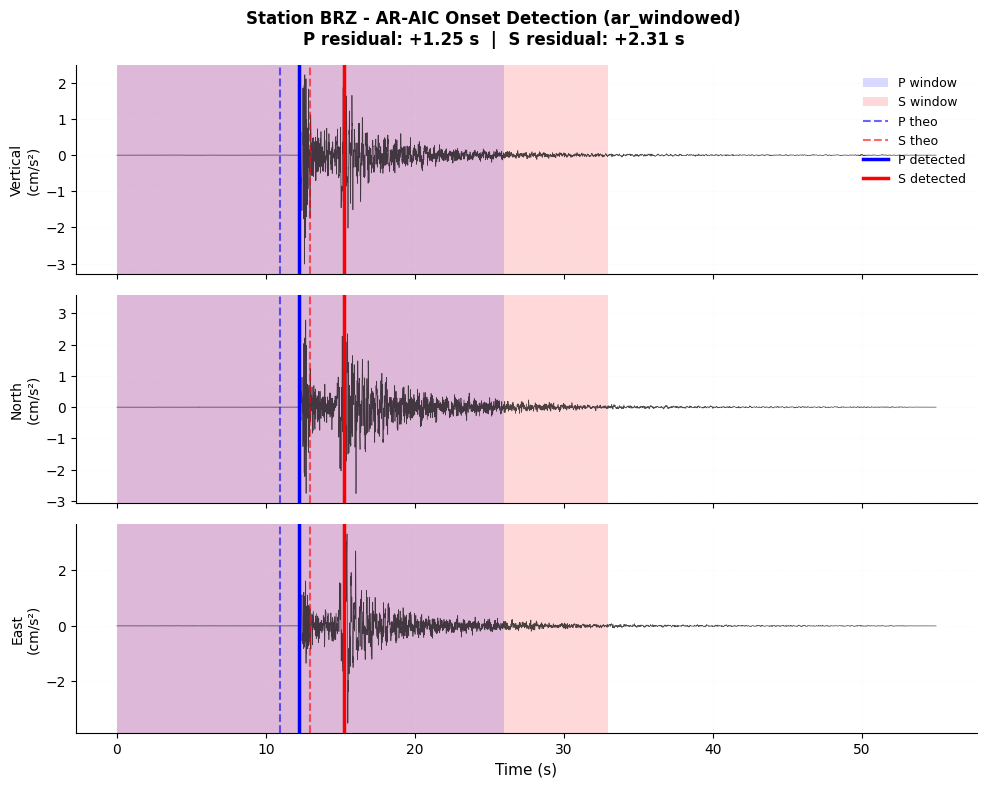

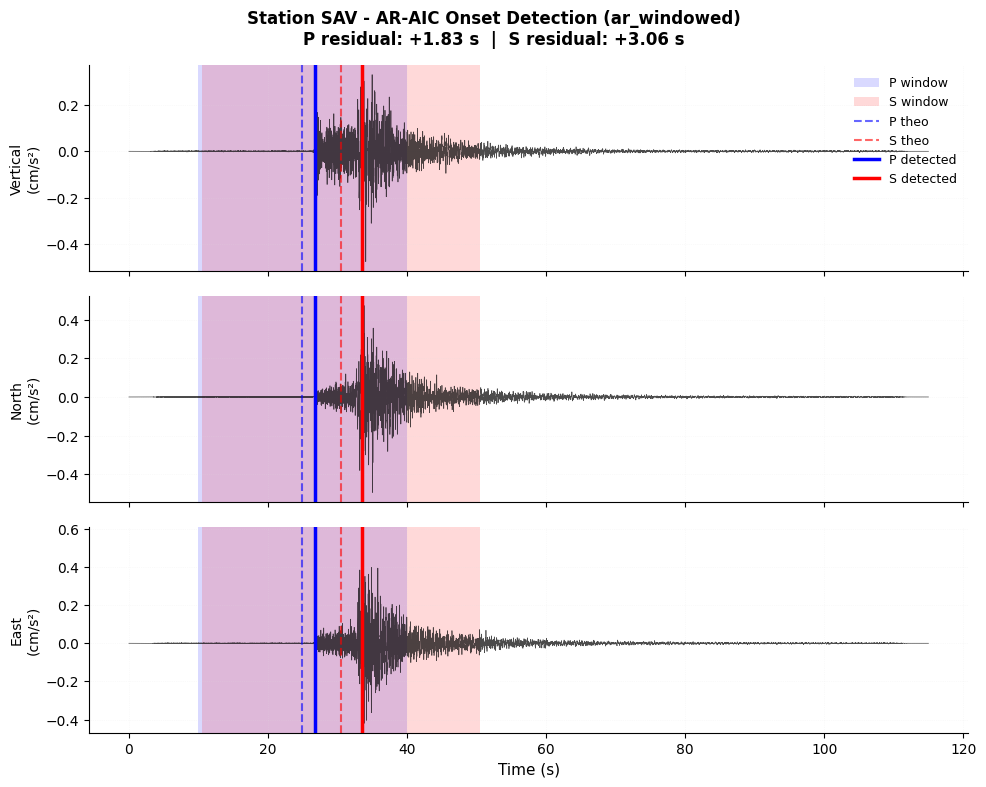

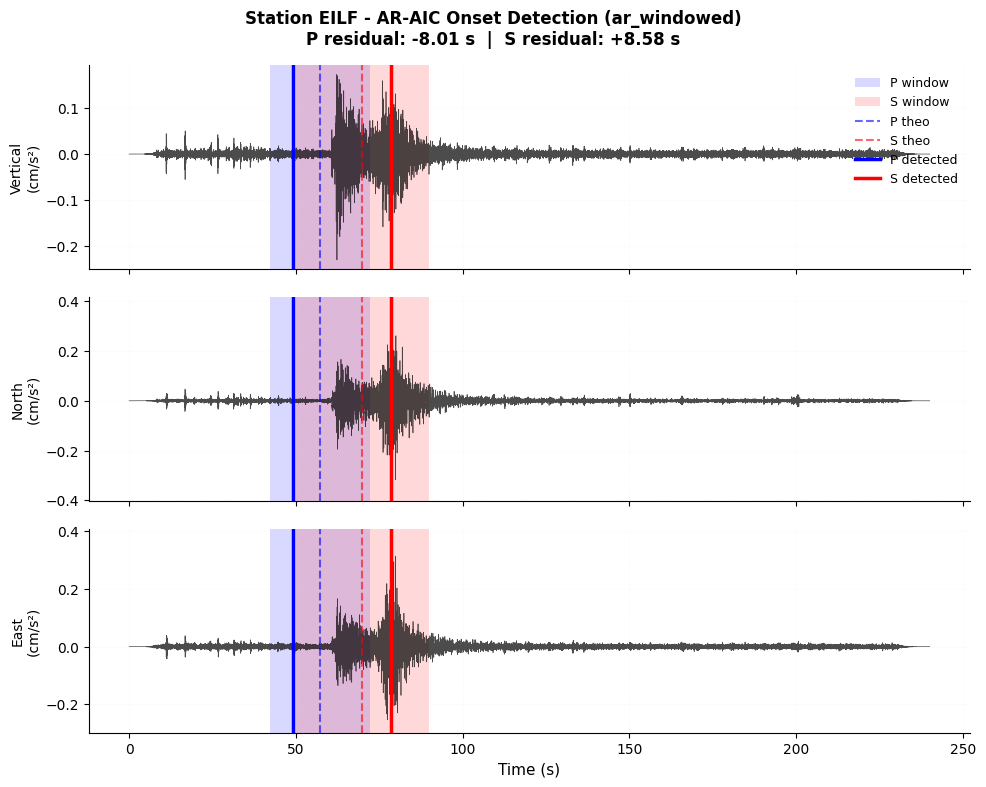

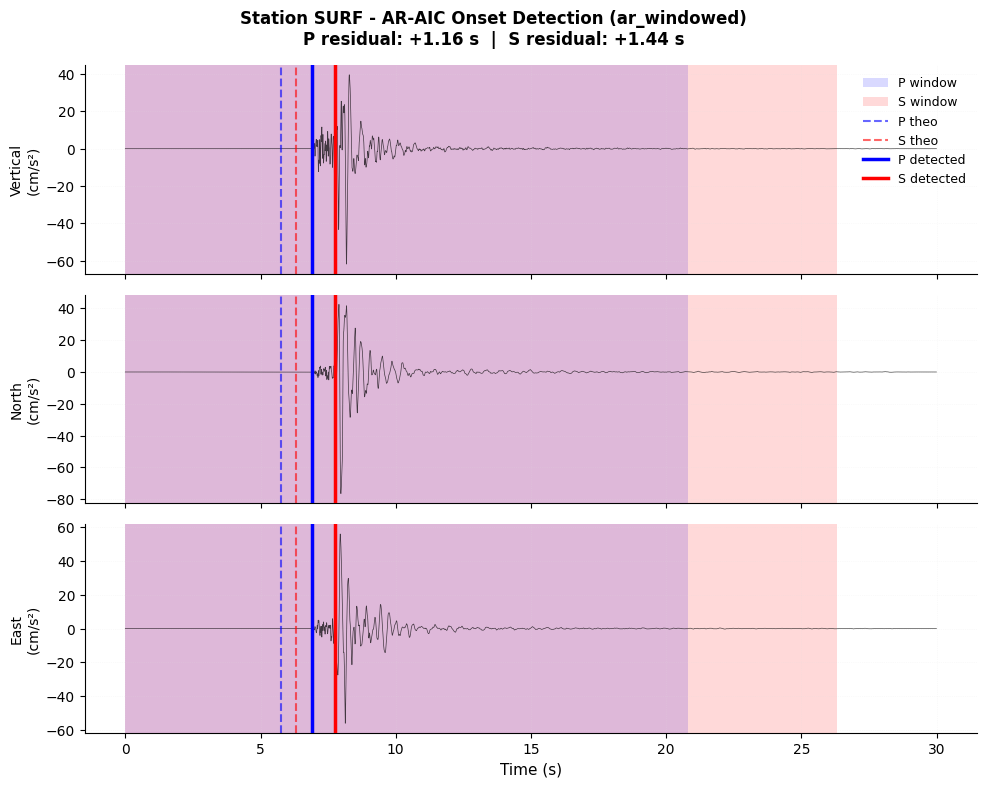

In [17]:
# Plot con finestre visibili
figures = plot_onset_detection_results(
    signals_dict, 
    df_results_windowed,
    stations=['BRZ', 'SAV', 'EILF', 'SURF'],
    show_windows=True,
    save_dir=FIGURES_DIR / 'onset_detection_windowed'
)

plt.show()

In [18]:
# Check EILF S detection
station = 'EILF'
row = df_results_windowed[df_results_windowed['STATION_CODE'] == station].iloc[0]

print(f"Station: {station}")
print(f"S window: {row['s_window_used']}")
print(f"S theo: {row['t_s_theo']:.2f}s")
print(f"S detected: {row['t_s_detected']:.2f}s")
print(f"S residual: {row['s_residual']:.2f}s")

# Parse window
import re
s_match = re.findall(r'[-+]?\d*\.?\d+', row['s_window_used'])
if len(s_match) == 2:
    s_win_start, s_win_end = float(s_match[0]), float(s_match[1])
    print(f"\nParsed S window: [{s_win_start:.2f}, {s_win_end:.2f}]")
    print(f"S detected in window? {s_win_start <= row['t_s_detected'] <= s_win_end}")
    
    # Check if it's at the END of the window
    window_length = s_win_end - s_win_start
    relative_position = row['t_s_detected'] - s_win_start
    print(f"Window length: {window_length:.2f}s")
    print(f"Relative position in window: {relative_position:.2f}s ({100*relative_position/window_length:.1f}%)")

Station: EILF
S window: [49.9, 89.9]
S theo: 69.89s
S detected: 78.48s
S residual: 8.58s

Parsed S window: [49.90, 89.90]
S detected in window? True
Window length: 40.00s
Relative position in window: 28.58s (71.4%)


In [19]:
# Manual re-run for EILF to see what's happening
station = 'EILF'
data = signals_dict[station]
time = data['time']

# Get metadata
station_meta = df_meta_stations[df_meta_stations['STATION_CODE'] == station].iloc[0]

# Get components
comp_z = 'HNZ'
comp_n = 'HNN'
comp_e = 'HNE'

signal_z_full = data[comp_z]
signal_n_full = data[comp_n]
signal_e_full = data[comp_e]

# S window
t_s_theo = station_meta['t_s_theo']
s_win_start = station_meta['s_window_start']
s_win_end = station_meta['s_window_end']

print(f"S theo: {t_s_theo:.2f}s")
print(f"S window: [{s_win_start:.2f}, {s_win_end:.2f}]")

# Extract S window subset
mask_s = (time >= s_win_start) & (time <= s_win_end)
print(f"\nMask S: {mask_s.sum()} samples")

signal_z_s = signal_z_full[mask_s]
signal_n_s = signal_n_full[mask_s]
signal_e_s = signal_e_full[mask_s]
time_s = time[mask_s]

print(f"Subset time range: [{time_s.min():.2f}, {time_s.max():.2f}]")
print(f"Subset length: {len(signal_z_s)} samples = {len(signal_z_s)/200:.2f}s")

# Run AR-AIC on subset
from obspy.signal.trigger import ar_pick

f1 = station_meta['LOW_CUT_FREQUENCY_HZ']
f2 = station_meta['HIGH_CUT_FREQUENCY_HZ']

p_pick_relative, s_pick_relative = ar_pick(
    signal_z_s, signal_n_s, signal_e_s,
    samp_rate=200,
    f1=f1,
    f2=f2,
    lta_p=1.0,
    sta_p=0.1,
    lta_s=4.0,
    sta_s=1.0,
    m_p=2,
    m_s=8,
    l_p=0.1,
    l_s=0.2
)

print(f"\nAR-AIC results (relative to subset):")
print(f"  P pick: {p_pick_relative:.2f}s")
print(f"  S pick: {s_pick_relative:.2f}s")

# Convert to absolute
t_s_detected = s_win_start + s_pick_relative
print(f"\nConversion to absolute:")
print(f"  s_win_start: {s_win_start:.2f}s")
print(f"  s_pick_relative: {s_pick_relative:.2f}s")
print(f"  t_s_detected: {t_s_detected:.2f}s")

# Check
print(f"\nIn window? {s_win_start <= t_s_detected <= s_win_end}")

# What does df_results say?
stored_value = df_results_windowed[df_results_windowed['STATION_CODE'] == station]['t_s_detected'].iloc[0]
print(f"\nStored in df_results: {stored_value:.2f}s")
print(f"Match? {abs(t_s_detected - stored_value) < 0.01}")

S theo: 69.89s
S window: [49.89, 89.89]

Mask S: 8000 samples
Subset time range: [49.90, 89.89]
Subset length: 8000 samples = 40.00s

AR-AIC results (relative to subset):
  P pick: 10.80s
  S pick: 28.58s

Conversion to absolute:
  s_win_start: 49.89s
  s_pick_relative: 28.58s
  t_s_detected: 78.48s

In window? True

Stored in df_results: 78.48s
Match? True


In [20]:
# Check the mask
s_win_start = 49.89
s_win_end = 89.89

print(f"Window: [{s_win_start}, {s_win_end}]")
print(f"Expected duration: {s_win_end - s_win_start:.2f}s")
print(f"Expected samples: {(s_win_end - s_win_start) * 200:.0f}")

# Check time array
print(f"\nTime array info:")
print(f"  Length: {len(time)}")
print(f"  Range: [{time.min():.2f}, {time.max():.2f}]")
print(f"  Sampling: {1/np.diff(time).mean():.1f} Hz")

# Check mask
mask_s = (time >= s_win_start) & (time <= s_win_end)
print(f"\nMask:")
print(f"  True count: {mask_s.sum()}")
print(f"  Expected: ~8000 samples (40s * 200Hz)")

# Check extracted times
time_s = time[mask_s]
print(f"\nExtracted time:")
print(f"  First: {time_s[0]:.6f}")
print(f"  Last: {time_s[-1]:.6f}")
print(f"  Duration: {time_s[-1] - time_s[0]:.6f}s")
print(f"  Samples: {len(time_s)}")

# Check if time array has duplicates or weird spacing
print(f"\nTime spacing check:")
dt = np.diff(time_s)
print(f"  Mean dt: {dt.mean():.6f}s (should be 0.005s for 200Hz)")
print(f"  Min dt: {dt.min():.6f}s")
print(f"  Max dt: {dt.max():.6f}s")

Window: [49.89, 89.89]
Expected duration: 40.00s
Expected samples: 8000

Time array info:
  Length: 48000
  Range: [0.00, 240.00]
  Sampling: 200.0 Hz

Mask:
  True count: 8001
  Expected: ~8000 samples (40s * 200Hz)

Extracted time:
  First: 49.890000
  Last: 89.890000
  Duration: 40.000000s
  Samples: 8001

Time spacing check:
  Mean dt: 0.005000s (should be 0.005s for 200Hz)
  Min dt: 0.005000s
  Max dt: 0.005000s
